# Snapshot eval violins — held-out eval-config comparison across GEN snapshots

Compares **per-episode eval metrics** of several GEN snapshots across the **held-out eval
configs** their eval runs covered, drawn side by side at each config. A GEN eval run writes one
result directory per infra config; **only the held-out ones** — directory names ending in
`_eval_<i>` (here `cfg_eval_0` … `cfg_eval_3`) — are used, anything else is skipped.

The x-axis carries the eval configs (`eval_0` … `eval_3`); at each config the sources are drawn
as **dodged violins side by side** — one per snapshot — mirroring
`sps_eval_violins_seed_compare.ipynb`, which fans out over seeds instead. As configured here: the
three **PPO** runs of the battery-capacity × PV generalisation trial (spec, N-way gen., gen.
distribution) on the four held-out settings. The SAC and DreamerV3 paths in the next cell swap in
the other algorithms.

All nine snapshots (`snapshots/20260719_*` / `20260720_*_gen_lin_bat_pv_*`, trial YAMLs
under `configs/trial_cfgs/v0/GEN/gs_lin_bat_pv/`) share one environment — battery max power
pinned at 10 kW, a 5 kW wind turbine, household consumers (8 kW peak), the
`EconomicRewardV0` reward and 7000 training episodes — and differ only in the battery capacity and
PV rating seen while training:

| Variant | Training battery capacity × PV rating |
|---|---|
| spec | single mid-grid config `cfg_5`: battery 15 kWh, PV 10 kW |
| N-way gen. | infra schedule cycling the 3 × 3 grid `cfg_1…9` — battery 10 / 15 / 20 kWh × PV 5 / 10 / 15 kW — every 12 episodes (`swap_every_n_episodes: 12`) |
| gen. distribution | `BatteryLinearWrapper` + `SolarPanelWrapper` drawing battery 10-20 kWh × PV 5-15 kW at every reset (uniform, rounded to 0.1), redrawn while on a held-out value (12 / 16 kWh, 6 / 12 kW); infra schedule `mode: "off"` |

The four held-out settings, identical in all nine snapshots:

| Setting | Infra YAML | Battery capacity | PV rating |
|---|---|---|---|
| `eval_0` | `cfg_eval_0.yaml` | 12 kWh | 6 kW |
| `eval_1` | `cfg_eval_1.yaml` | 16 kWh | 12 kW |
| `eval_2` | `cfg_eval_2.yaml` | 12 kWh | 12 kW |
| `eval_3` | `cfg_eval_3.yaml` | 16 kWh | 6 kW |

Each **source** is one snapshot evaluated under one eval kind (plus a rule-based strategy for
`eval-rbc`):

| `eval-kind` | Run directory pattern | Producer | Per-eval-config CSV | Seed metadata |
|---|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>[_seed<N>]/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-sb` | `runs/eval_sb_<ts>[_seed<N>]/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | sidecar JSON `"seed"` |
| `eval-rbc` | `runs/eval_rbc_<ts>[_seed<N>]/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/<name>_eval_<i>/episodes.csv` | `args.json` `"resolved_seed"` |

Every run's seed comes from its **own metadata**, never from the directory name. With
`SEEDS = None` a snapshot's whole `_seed<N>` fan-out pools into one violin per eval config;
a single seed (`SEEDS = 42`, as set here) or a list narrows that. Sources with no run on a
wanted seed drop out with a warning, leaving a gap in their x-axis slot.

**Main input:** `SOURCES`, `SEEDS`, `EXCLUDE_EVAL_CFGS` and the x-tick renaming
`EVAL_CFG_LABELS` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# The sources to compare side by side at each held-out eval config. Each source is one
# snapshot evaluated under one eval kind; at every eval config the x-axis draws one
# violin per source. Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* dirs to use
#   label         short name shown in the legend and used as the per-config violin group
#   color         violin fill colour for this source
#   rbc-strategy  (eval-rbc only) which rule-based strategy to compare across configs

# SAC paths:
# snapshots/20260719_171327_gen_lin_bat_pv_spec_sac
# snapshots/20260719_171314_gen_lin_bat_pv_all_sac
# snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac

# PPO paths:
# snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo
# snapshots/20260719_171650_gen_lin_bat_pv_all_ppo
# snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo

# DreamerV3 paths:
# snapshots/20260720_171656_gen_lin_bat_pv_spec_dreamer
# snapshots/20260720_171650_gen_lin_bat_pv_all_dreamer
# snapshots/20260720_171702_gen_lin_bat_pv_sampled_dreamer

SOURCES = [
    {
        "path": "snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo",
        "eval-kind": "eval-ray",
        "label": "spec",
        "color": "#75aef4",  # RL blue, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260719_171650_gen_lin_bat_pv_all_ppo",
        "eval-kind": "eval-ray",
        "label": "N-way gen.",
        "color": "#f1bd2d",  # RL orange, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo",
        "eval-kind": "eval-ray",
        "label": "gen. distribution",
        "color": "#89f0cc",  # green, matching snapshot_eval_violins.ipynb
    },
]

# Eval configs to exclude from every figure and table below (applied after discovery, to
# all sources). Leave empty to keep all discovered configs, e.g. EXCLUDE_EVAL_CFGS = ["eval_3"].
EXCLUDE_EVAL_CFGS: list[str] = []

# Eval seeds to keep, applied after discovery to all sources:
#   SEEDS = None       keep every discovered seed (default) — a snapshot's whole
#                      `_seed<N>` fan-out pools into one violin per eval config
#   SEEDS = 42         keep only the eval run seeded 42
#   SEEDS = [42, 43]   keep those two seeds, pooled per violin
# Matched against the seed every run recorded itself (sidecar JSON "seed" for
# eval-ray/eval-sb, args.json "resolved_seed" for eval-rbc), never the directory name.
SEEDS: int | list[int] | None = 42

# Optional display names for the x-axis ticks, keyed by the discovered `eval_<i>` label.
# Only affects the figures — tables and PDF filenames keep the `eval_<i>` keys. Configs
# not listed keep their default label. Here: the held-out (battery capacity, PV rating) pairs
# of configs/infra_cfgs/GEN/battery_lin_cap_lin_pv_so/cfg_eval_<i>.yaml (battery max power 10 kW).
EVAL_CFG_LABELS: dict[str, str] = {
    "eval_0": "BES 12 kWh\nPV 6 kW",
    "eval_1": "BES 16 kWh\nPV 12 kW",
    "eval_2": "BES 12 kWh\nPV 12 kW",
    "eval_3": "BES 16 kWh\nPV 6 kW",
}

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_cap_eval_1);
# training-config directories (e.g. battery_lin_cap_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# Ray/SB3 eval CSVs carry a sidecar JSON (same stem) with the trial seed the run used.
def _sidecar_seed(csv_path: Path) -> int | None:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None
    try:
        return json.loads(sidecar.read_text()).get("seed")
    except (json.JSONDecodeError, OSError):
        return None


# Rule-based runs record resolved_seed in an args.json above episodes.csv (one level up
# in the flat layout, two with the per-config dirs used here) — walk up towards the run
# dir and take the first hit, so both layouts resolve.
def _rbc_resolved_seed(csv_path: Path, run_dir: Path) -> int | None:
    for candidate_dir in csv_path.parents:
        args_path = candidate_dir / "args.json"
        if args_path.is_file():
            try:
                return json.loads(args_path.read_text()).get("resolved_seed")
            except (json.JSONDecodeError, OSError):
                return None
        if candidate_dir == run_dir:
            return None
    return None


# Discovers one record per (run, held-out eval config) CSV for a single source. The
# eval-config label is parsed from the per-config result directory name
# (`..._eval_<i>` -> `eval_<i>`); non-matching (training-config) directories are skipped.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            csv_paths = sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            strategies = sorted({csv_path.parent.parent.name for csv_path in csv_paths})
            strategy = source.get("rbc-strategy")
            if strategy is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['label']}': multiple rule-based strategies {strategies} under "
                    f"{run_dir.name} — set 'rbc-strategy' to pick one."
                )
            csv_paths = [csv_path for csv_path in csv_paths
                        if strategy is None or csv_path.parent.parent.name == strategy]
        else:
            csv_paths = sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
        for csv_path in csv_paths:
            match = _EVAL_CFG_DIR_PATTERN.search(csv_path.parent.name)
            if match is None:
                continue  # training-config result dir — not a held-out eval config
            seed = (_rbc_resolved_seed(csv_path, run_dir) if eval_kind == "eval-rbc"
                    else _sidecar_seed(csv_path))
            records.append({
                "source": source["label"], "snapshot_dir": snapshot_dir, "run": run_dir.name,
                "eval_cfg": f"eval_{match.group(1)}", "eval_index": int(match.group(1)),
                "cfg_dir": csv_path.parent.name, "seed": seed, "csv": csv_path,
            })
    if not records:
        raise FileNotFoundError(
            f"No held-out eval-config CSVs (*_eval_<i>) discovered for source '{source['label']}' "
            f"({eval_kind}) under {snapshot_dir}"
        )
    return records


source_labels = [source["label"] for source in SOURCES]
if len(source_labels) != len(set(source_labels)):
    raise ValueError(f"Every source needs a unique 'label' (it names the per-config violin group); got {source_labels}")
source_palette = {source["label"]: source["color"] for source in SOURCES}

eval_records: list[dict] = []
for source in SOURCES:
    eval_records.extend(_discover_source_records(source))

print(f"Repo root: {REPO_ROOT}")
for source in SOURCES:
    records = [record for record in eval_records if record["source"] == source["label"]]
    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['label']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in sorted(records, key=lambda record: (record["eval_index"], record["run"])):
        print(f"  {record['eval_cfg']:>8}  seed {str(record['seed']):>5}  <-  {record['run']} / {record['cfg_dir']}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym

Source 'spec' (eval-ray): snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo
    eval_0  seed    42  <-  eval_20260721_103512 / cfg_eval_0
    eval_1  seed    42  <-  eval_20260721_103512 / cfg_eval_1
    eval_2  seed    42  <-  eval_20260721_103512 / cfg_eval_2
    eval_3  seed    42  <-  eval_20260721_103512 / cfg_eval_3

Source 'N-way gen.' (eval-ray): snapshots/20260719_171650_gen_lin_bat_pv_all_ppo
    eval_0  seed    42  <-  eval_20260721_103510 / cfg_eval_0
    eval_1  seed    42  <-  eval_20260721_103510 / cfg_eval_1
    eval_2  seed    42  <-  eval_20260721_103510 / cfg_eval_2
    eval_3  seed    42  <-  eval_20260721_103510 / cfg_eval_3

Source 'gen. distribution' (eval-ray): snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo
    eval_0  seed    42  <-  eval_20260721_103514 / cfg_eval_0
    eval_1  seed    42  <-  eval_20260721_103514 / cfg_eval_1
    eval_2  seed    42  <-  eval_20260721_103514 / cfg_eval_2
    eval_3

## Output naming

Everything saved here lands next to the notebook as `<date>_<time>_out_<i>.<file format>`:
one timestamp per notebook run, `out_index` counting up per saved artefact, so no run
overwrites an earlier one.

In [3]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


## Align the eval configs

One violin group per (source, eval config). The x-axis is the numerically sorted union
of the `eval_<i>` labels seen across the sources (after dropping any in
`EXCLUDE_EVAL_CFGS`); a warning is printed if the sources do not cover exactly the same
configs — seaborn simply leaves a gap where a source has no results for a config. A
source with multiple CSVs for one config (several eval runs or checkpoints, e.g. a
`_seed<N>` fan-out) pools their episodes into a single violin, with a warning.

`SEEDS` is applied here too, before that check: it keeps only the runs whose recorded
seed is wanted (`None` keeps all), so pinning a single seed also clears the pooling
warning a seed fan-out would otherwise raise. Runs whose seed cannot be resolved are
kept while `SEEDS` is `None` and dropped with a note once it is set, since they can
never match.

In [4]:
# Drop any explicitly excluded eval configs (EXCLUDE_EVAL_CFGS) from every figure and table below.
_excluded_set = set(EXCLUDE_EVAL_CFGS)
_dropped = sorted({record["eval_cfg"] for record in eval_records if record["eval_cfg"] in _excluded_set})
if _dropped:
    print(f"Excluding eval config(s) {_dropped} (EXCLUDE_EVAL_CFGS).")
eval_records = [record for record in eval_records if record["eval_cfg"] not in _excluded_set]
if not eval_records:
    raise ValueError(f"EXCLUDE_EVAL_CFGS={EXCLUDE_EVAL_CFGS} removed every discovered CSV — nothing left to plot.")

# Narrow to the wanted eval seeds (SEEDS): a bare int selects one seed, any iterable of
# ints selects several, None keeps every discovered seed. Runs with an unresolvable seed
# cannot match a filter, so they are dropped with a note once one is set.
_seed_filter: set[int] | None = (
    None if SEEDS is None else {int(seed) for seed in ([SEEDS] if isinstance(SEEDS, int) else SEEDS)}
)
if _seed_filter is not None:
    if not _seed_filter:
        raise ValueError("SEEDS is empty — use None to keep every discovered seed, or name the seed(s) to keep.")
    for record in eval_records:
        if record["seed"] is None:
            print(f"note: source '{record['source']}': dropped {record['run']} / {record['cfg_dir']} "
                  "(no seed resolvable — cannot match SEEDS)")
    _seeds_available = sorted({record["seed"] for record in eval_records if record["seed"] is not None})
    eval_records = [record for record in eval_records if record["seed"] in _seed_filter]
    print(f"Keeping eval seed(s) {sorted(_seed_filter)} (SEEDS); discovered: {_seeds_available or 'none'}.")
    if not eval_records:
        raise ValueError(f"SEEDS={SEEDS} removed every discovered CSV (seeds available: "
                         f"{_seeds_available or 'none'}) — nothing left to plot.")
    for source in SOURCES:
        if not any(record["source"] == source["label"] for record in eval_records):
            print(f"WARNING: source '{source['label']}' has no run on seed(s) {sorted(_seed_filter)} — "
                  "it is absent from every figure and table below.")

# One violin per (source, eval config): flag sources with multiple CSVs for one config
# (their episodes would pool into a single violin for that config).
for source in SOURCES:
    cfgs = [record["eval_cfg"] for record in eval_records if record["source"] == source["label"]]
    duplicates = sorted({cfg for cfg in cfgs if cfgs.count(cfg) > 1})
    if duplicates:
        print(f"WARNING: source '{source['label']}' has multiple CSVs for eval config(s) {duplicates} — "
              "their episodes are pooled into one violin per config.")

# x-axis: the numerically sorted union of eval configs; warn where a source does not cover the union.
eval_cfg_order = [f"eval_{index}" for index in sorted({record["eval_index"] for record in eval_records})]
for source in SOURCES:
    source_cfgs = {record["eval_cfg"] for record in eval_records if record["source"] == source["label"]}
    missing = [cfg for cfg in eval_cfg_order if cfg not in source_cfgs]
    if missing:
        print(f"WARNING: source '{source['label']}' has no results for eval config(s) {missing} — "
              "those slots show only the other sources' violins.")


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


pd.DataFrame(
    {"source": record["source"], "eval_cfg": record["eval_cfg"], "seed": record["seed"],
     "run": record["run"], "csv": _display_path(record["csv"])}
    for record in sorted(eval_records, key=lambda record: (record["eval_index"], source_labels.index(record["source"])))
)

Keeping eval seed(s) [42] (SEEDS); discovered: [42].


,source,eval_cfg,seed,run,csv
0,spec,eval_0,42,eval_20260721_103512,snapshots/20260719_171656_gen_lin_bat_pv_spec_...
1,N-way gen.,eval_0,42,eval_20260721_103510,snapshots/20260719_171650_gen_lin_bat_pv_all_p...
2,gen. distribution,eval_0,42,eval_20260721_103514,snapshots/20260719_171702_gen_lin_bat_pv_sampl...
3,spec,eval_1,42,eval_20260721_103512,snapshots/20260719_171656_gen_lin_bat_pv_spec_...
4,N-way gen.,eval_1,42,eval_20260721_103510,snapshots/20260719_171650_gen_lin_bat_pv_all_p...
5,gen. distribution,eval_1,42,eval_20260721_103514,snapshots/20260719_171702_gen_lin_bat_pv_sampl...
6,spec,eval_2,42,eval_20260721_103512,snapshots/20260719_171656_gen_lin_bat_pv_spec_...
7,N-way gen.,eval_2,42,eval_20260721_103510,snapshots/20260719_171650_gen_lin_bat_pv_all_p...
8,gen. distribution,eval_2,42,eval_20260721_103514,snapshots/20260719_171702_gen_lin_bat_pv_sampl...
9,spec,eval_3,42,eval_20260721_103512,snapshots/20260719_171656_gen_lin_bat_pv_spec_...


## Load per-episode metrics

The CSVs are concatenated into one frame with a row per episode and the three metrics as
columns, each row tagged with its `source`, `eval_cfg` and eval `seed`. A CSV missing a metric
column is simply absent from that metric's figure. The table gives episode count, number of
pooled seeds and per-metric mean for every violin.

In [5]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['source']}' {record['eval_cfg']} lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["source"] = record["source"]
    frame["eval_cfg"] = record["eval_cfg"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

episodes.groupby(["eval_cfg", "source"], sort=True).agg(
    episodes=("eval_cfg", "size"),
    eval_seeds=("seed", "nunique"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
)

episodes  eval_seeds  mean_total_reward  \
eval_cfg source                                                       
eval_0   N-way gen.               10           1          11.666406   
         gen. distribution        10           1          11.895229   
         spec                     10           1          11.704065   
eval_1   N-way gen.               10           1          21.651009   
         gen. distribution        10           1          21.760578   
         spec                     10           1          21.397569   
eval_2   N-way gen.               10           1          18.726408   
         gen. distribution        10           1          19.085956   
         spec                     10           1          18.693778   
eval_3   N-way gen.               10           1          14.607024   
         gen. distribution        10           1          14.180966   
         spec                     10           1          14.247648   

                            mean_cum_E_kWh  mean_cum_price_EUR  
eval_cfg source                                                 
eval_0   N-way gen.              36.154623           -2.658576  
         gen. distribution       36.154623           -2.537521  
         spec                    35.134623           -2.426803  
eval_1   N-way gen.              76.899877           -4.907875  
         gen. distribution       76.899877           -4.677818  
         spec                    75.539877           -4.507803  
eval_2   N-way gen.              76.145481           -4.260017  
         gen. distribution       76.145481           -4.167817  
         spec                    75.125481           -4.016744  
eval_3   N-way gen.              36.909020           -3.313558  
         gen. distribution       36.909020           -2.983158  
         spec                    35.549020           -2.878815

## Violin plots

At each held-out eval config the sources are drawn as **dodged violins side by side** in their
`SOURCES` colours, separated by `VIOLIN_GAP`, with the individual episodes overlaid as dodged
dots. Every violin carries a red **mean** dot and a dashed **median** line. X ticks default to
the `eval_<i>` labels and are renamed through `EVAL_CFG_LABELS` (here to the held-out battery
capacity × PV rating pairs). The figures carry **no title** (thesis-ready) and are saved as
`<date>_<time>_out_<i>.pdf` next to this notebook.

In [6]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

METRIC_LABELS = {
    "total_reward": "Total reward per episode",
    "cum_E_kWh": "Net grid energy exchange [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn violinplot default `width` — the per-config slot the sources share
VIOLIN_GAP = 0.2   # shrink factor on each dodged violin (seaborn `gap`) — space between neighbours
_cfg_position = {cfg: index for index, cfg in enumerate(eval_cfg_order)}


# Centre offset of a source's dodged violin within an eval config's slot, so the stat markers
# land on the exact violin seaborn draws for that (config, source). Matches seaborn's even hue
# split; `gap` shrinks each violin around this same centre, so the offset is gap-independent.
def _dodge_offset(source_label: str) -> float:
    hue_index = source_labels.index(source_label)
    return DODGE_WIDTH * ((hue_index + 0.5) / len(source_labels) - 0.5)


# Overlays each dodged violin's mean (red dot) and median (narrow dashed line).
def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    half_width = 0.9 * (1 - VIOLIN_GAP) * (DODGE_WIDTH / len(source_labels)) / 2
    stats = data.groupby(["eval_cfg", "source"])[metric].agg(["mean", "median"])
    for (eval_cfg, source), row in stats.iterrows():
        if eval_cfg not in _cfg_position or source not in source_labels:
            continue
        x_position = _cfg_position[eval_cfg] + _dodge_offset(source)
        ax.hlines(
            row["median"], x_position - half_width, x_position + half_width,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


# Draws one violin per source at each held-out eval config for `metric` (no figure
# title) and exports the figure as a PDF next to this notebook.
def violin_for_metric(metric: str) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(8.0, 0.9 * len(eval_cfg_order) * len(source_labels))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="eval_cfg",
        y=metric,
        hue="source",
        order=eval_cfg_order,
        hue_order=source_labels,
        palette=source_palette,
        dodge=True,  # one violin per source, side by side per eval config
        gap=VIOLIN_GAP,  # space between the dodged violins
        density_norm="area",
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="eval_cfg", y=metric, hue="source",
        order=eval_cfg_order, hue_order=source_labels, dodge=True,
        palette={source: "0.1" for source in source_labels},
        size=3, alpha=0.6, jitter=0.08, legend=False, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("Eval configs")
    # Rename the x ticks via EVAL_CFG_LABELS (display only — data keys stay `eval_<i>`).
    ax.set_xticks(range(len(eval_cfg_order)), [EVAL_CFG_LABELS.get(cfg, cfg) for cfg in eval_cfg_order])
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)

    # Legend: the source colours seaborn built + the mean/median stat markers, outside the axes.
    source_handles, source_legend_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
               markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    ax.legend(
        handles=source_handles + stat_handles,
        labels=source_legend_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({metric})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/6_gen_bat_cap_pv_power/20261008_153603_out_1.pdf  (total_reward)


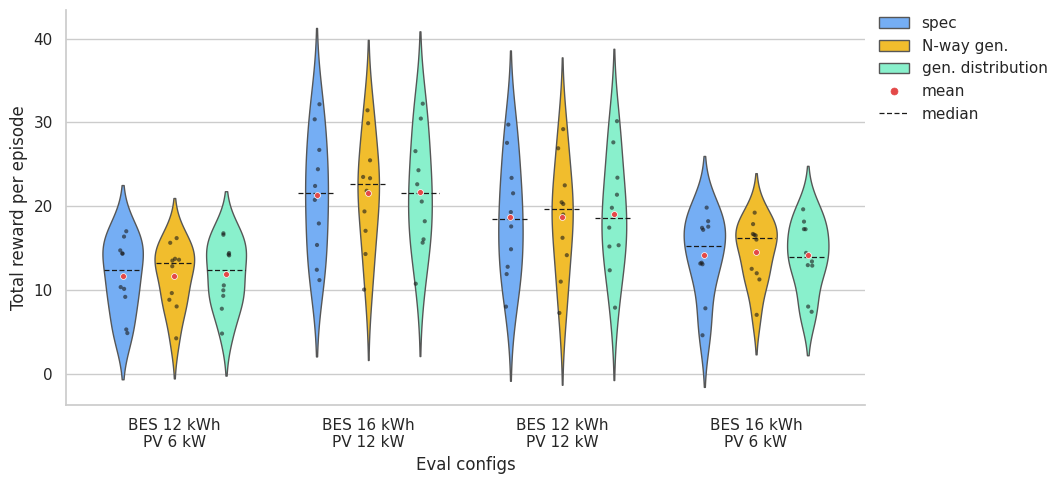

In [7]:
violin_for_metric("total_reward")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/6_gen_bat_cap_pv_power/20261008_153603_out_2.pdf  (cum_E_kWh)


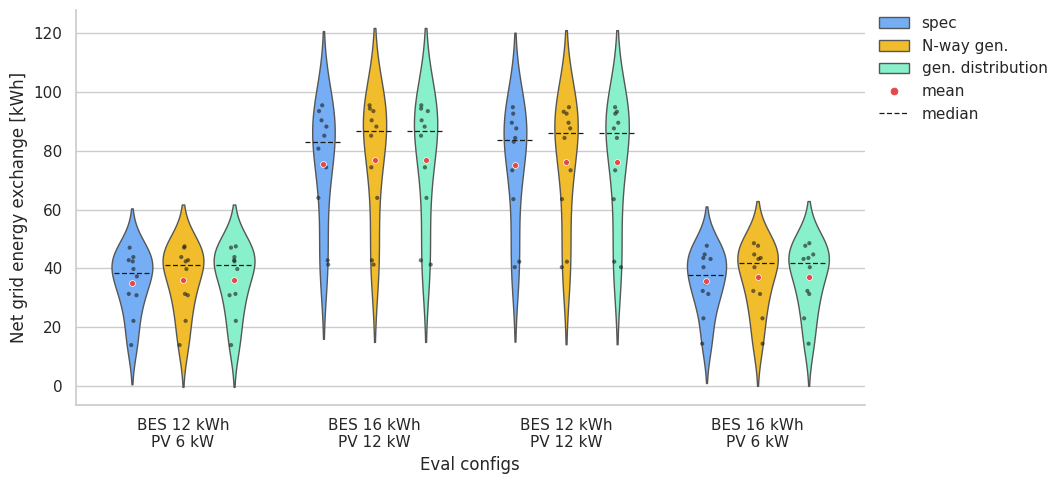

In [8]:
violin_for_metric("cum_E_kWh")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/6_gen_bat_cap_pv_power/20261008_153603_out_3.pdf  (cum_price_EUR)


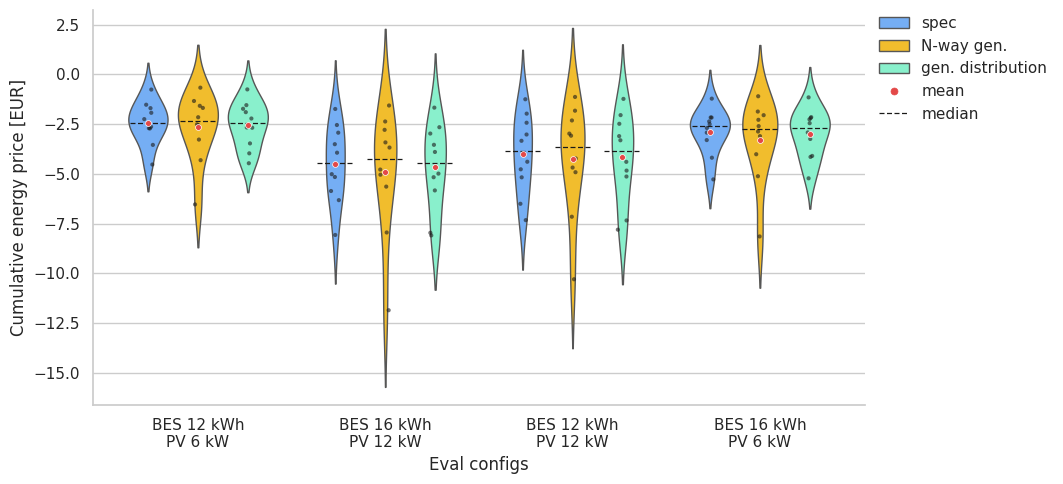

In [9]:
violin_for_metric("cum_price_EUR")

## Variance across eval configs, per source

For each source the metric mean is first taken within each held-out eval config, then those
config means are aggregated (`mean` / `std` / `median` / `min` / `max`) across configs — a small
`std` means the snapshot performs consistently over the four held-out battery-capacity × PV settings.

In [10]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
cfg_means = episodes.groupby(["source", "eval_cfg"])[present_metrics].mean()
cfg_means.groupby("source").agg(["mean", "std", "median", "min", "max"])

total_reward                                             \
                          mean       std     median        min        max   
source                                                                      
N-way gen.           16.662712  4.409493  16.666716  11.666406  21.651009   
gen. distribution    16.730682  4.499253  16.633461  11.895229  21.760578   
spec                 16.510765  4.354020  16.470713  11.704065  21.397569   

                  cum_E_kWh                                             \
                       mean        std    median        min        max   
source                                                                   
N-way gen.         56.52725  23.092840  56.52725  36.154623  76.899877   
gen. distribution  56.52725  23.092840  56.52725  36.154623  76.899877   
spec               55.33725  23.089972  55.33725  35.134623  75.539877   

                  cum_price_EUR                                          
                           mean       std    median       min       max  
source                                                                   
N-way gen.            -3.785007  0.996256 -3.786787 -4.907875 -2.658576  
gen. distribution     -3.591579  0.998863 -3.575488 -4.677818 -2.537521  
spec                  -3.457541  0.968350 -3.447780 -4.507803 -2.426803

## Per-violin statistics

One row per (eval config, source) — i.e. per violin drawn above — over that violin's episodes:
`mean` (the red dot), `std`, `median` (the dashed line), `min` and `max` for every metric. Rows
follow the plot order: x-axis configs first, then the `SOURCES` hue order within each config.

In [11]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
violin_stats = episodes.groupby(["eval_cfg", "source"])[present_metrics].agg(
    ["mean", "std", "median", "min", "max"]
)
# Match the plot order: x-axis configs (numeric), then the SOURCES hue order per config.
violin_stats = violin_stats.reindex(eval_cfg_order, level="eval_cfg").reindex(source_labels, level="source")
violin_stats

total_reward                                  \
                                   mean       std     median        min   
eval_cfg source                                                           
eval_0   spec                 11.704065  4.360074  12.380550   4.913081   
         N-way gen.           11.666406  3.786299  13.212182   4.291341   
         gen. distribution    11.895229  3.968498  12.382108   4.857395   
eval_1   spec                 21.397569  7.202292  21.607329  11.223243   
         N-way gen.           21.651009  6.651557  22.612324  10.098319   
         gen. distribution    21.760578  6.826471  21.611348  10.791723   
eval_2   spec                 18.693778  6.996497  18.469385   8.063914   
         N-way gen.           18.726408  6.773670  19.660465   7.308916   
         gen. distribution    19.085956  6.834245  18.658974   7.943807   
eval_3   spec                 14.247648  4.873633  15.255133   4.653328   
         N-way gen.           14.607024  3.726961  16.292529   7.085906   
         gen. distribution    14.180966  4.102905  13.953972   7.452277   

                                       cum_E_kWh                        \
                                  max       mean        std     median   
eval_cfg source                                                          
eval_0   spec               17.042272  35.134623  10.570076  38.531006   
         N-way gen.         16.224051  36.154623  11.268931  41.074319   
         gen. distribution  16.801401  36.154623  11.268931  41.074319   
eval_1   spec               32.169417  75.539877  19.991617  82.884363   
         N-way gen.         31.447118  76.899877  20.826341  86.622744   
         gen. distribution  32.238877  76.899877  20.826341  86.622744   
eval_2   spec               29.749485  75.125481  20.060103  83.675344   
         N-way gen.         29.203538  76.145481  20.753821  85.943948   
         gen. distribution  30.152514  76.145481  20.753821  85.943948   
eval_3   spec               19.859645  35.549020  10.594196  37.667719   
         N-way gen.         19.257495  36.909020  11.353735  41.788960   
         gen. distribution  19.654807  36.909020  11.353735  41.788960   

                                                 cum_price_EUR            \
                                  min        max          mean       std   
eval_cfg source                                                            
eval_0   spec               13.932370  47.035556     -2.426803  1.068949   
         N-way gen.         13.932370  47.477993     -2.658576  1.709666   
         gen. distribution  13.932370  47.477993     -2.537521  1.155526   
eval_1   spec               41.279681  95.418884     -4.507803  1.940543   
         N-way gen.         41.279681  95.418884     -4.907875  3.056317   
         gen. distribution  41.279681  95.418884     -4.677818  2.163526   
eval_2   spec               40.403062  94.773174     -4.016744  1.973149   
         N-way gen.         40.403062  94.773174     -4.260017  2.750192   
         gen. distribution  40.403062  94.773174     -4.167817  2.176151   
eval_3   spec               14.394151  47.681266     -2.878815  1.148840   
         N-way gen.         14.394151  48.544928     -3.313558  2.042926   
         gen. distribution  14.394151  48.544928     -2.983158  1.209921   

                                                           
                              median        min       max  
eval_cfg source                                            
eval_0   spec              -2.438334  -4.529410 -0.759501  
         N-way gen.        -2.331574  -6.537092 -0.663388  
         gen. distribution -2.439886  -4.465392 -0.750893  
eval_1   spec              -4.475072  -8.072882 -1.734973  
         N-way gen.        -4.228895 -11.860217 -1.561074  
         gen. distribution -4.442750  -8.096621 -1.668265  
eval_2   spec              -3.863129  -7.327641 -1.246580  
         N-way gen.        -3.651902 -10.301448 -